# Hybrid CNN-CBAM-Swin Transformer for Multi-Class GI Disease Classification (Kvasir Dataset)

Following the same experimental design as the reference dental caries segmentation paper (SwinUNet-CBAM), adapted from pixel-wise segmentation to image-wise 8-class classification.

**Pipeline:** CLAHE preprocessing -> Augmentation (Albumentations) -> CNN+CBAM Encoder -> Swin Transformer Bottleneck -> Classification Head -> AdamW + warmup/cosine schedule -> Evaluation (Accuracy, Precision, Recall, F1, Specificity, AUC, Confusion Matrix)


In [1]:
# ============================================================
# 1. SETUP & IMPORTS
# ============================================================
import os, glob, math, random
import numpy as np
import pandas as pd
import cv2
import matplotlib.pyplot as plt
import seaborn as sns

import tensorflow as tf
from tensorflow.keras import layers, models, optimizers, callbacks
from tensorflow.keras.utils import to_categorical

from sklearn.model_selection import train_test_split
from sklearn.metrics import (accuracy_score, precision_recall_fscore_support,
                              confusion_matrix, roc_auc_score, roc_curve, classification_report)

import albumentations as A

SEED = 42
random.seed(SEED); np.random.seed(SEED); tf.random.set_seed(SEED)

IMG_SIZE = 256
BATCH_SIZE = 8
NUM_CLASSES = 8
EPOCHS = 200

print("TF version:", tf.__version__)
print("GPU available:", tf.config.list_physical_devices('GPU'))


TF version: 2.20.0
GPU available: [PhysicalDevice(name='/physical_device:GPU:0', device_type='GPU')]


In [2]:
# ============================================================
# 2. LOCATE DATASET (auto-discovers class folders under /kaggle/input)
# ============================================================
BASE_DIR = "/kaggle/input"

candidate_dirs = glob.glob(os.path.join(BASE_DIR, "**"), recursive=False)
print("Top-level input dirs:", candidate_dirs)

# Find all subfolders that look like class folders (contain images directly)
def find_class_folders(root):
    class_folders = []
    for dirpath, dirnames, filenames in os.walk(root):
        img_files = [f for f in filenames if f.lower().endswith(('.jpg', '.jpeg', '.png'))]
        if len(img_files) > 20:  # heuristic: a real class folder, not a wrapper dir
            class_folders.append(dirpath)
    return class_folders

class_folders = []
for d in candidate_dirs:
    class_folders.extend(find_class_folders(d))

class_folders = sorted(set(class_folders))
print(f"Found {len(class_folders)} class folders:")
for cf in class_folders:
    n = len([f for f in os.listdir(cf) if f.lower().endswith(('.jpg','.jpeg','.png'))])
    print(f"  {cf}  -> {n} images")


Top-level input dirs: ['/kaggle/input/datasets']
Found 8 class folders:
  /kaggle/input/datasets/meetnagadia/kvasir-dataset/kvasir-dataset/dyed-lifted-polyps  -> 500 images
  /kaggle/input/datasets/meetnagadia/kvasir-dataset/kvasir-dataset/dyed-resection-margins  -> 500 images
  /kaggle/input/datasets/meetnagadia/kvasir-dataset/kvasir-dataset/esophagitis  -> 500 images
  /kaggle/input/datasets/meetnagadia/kvasir-dataset/kvasir-dataset/normal-cecum  -> 500 images
  /kaggle/input/datasets/meetnagadia/kvasir-dataset/kvasir-dataset/normal-pylorus  -> 500 images
  /kaggle/input/datasets/meetnagadia/kvasir-dataset/kvasir-dataset/normal-z-line  -> 500 images
  /kaggle/input/datasets/meetnagadia/kvasir-dataset/kvasir-dataset/polyps  -> 500 images
  /kaggle/input/datasets/meetnagadia/kvasir-dataset/kvasir-dataset/ulcerative-colitis  -> 500 images


In [3]:
# ============================================================
# 3. BUILD FILE LIST + LABELS
# ============================================================
CLASS_NAMES = sorted([os.path.basename(cf) for cf in class_folders])
class_to_idx = {c: i for i, c in enumerate(CLASS_NAMES)}
print("Classes:", CLASS_NAMES)

filepaths, labels = [], []
for cf in class_folders:
    cname = os.path.basename(cf)
    imgs = glob.glob(os.path.join(cf, "*.jpg")) + glob.glob(os.path.join(cf, "*.jpeg")) + glob.glob(os.path.join(cf, "*.png"))
    for p in imgs:
        filepaths.append(p)
        labels.append(class_to_idx[cname])

df = pd.DataFrame({"filepath": filepaths, "label": labels})
print(df['label'].value_counts())
print("Total images:", len(df))


Classes: ['dyed-lifted-polyps', 'dyed-resection-margins', 'esophagitis', 'normal-cecum', 'normal-pylorus', 'normal-z-line', 'polyps', 'ulcerative-colitis']
label
0    500
1    500
2    500
3    500
4    500
5    500
6    500
7    500
Name: count, dtype: int64
Total images: 4000


In [4]:
# ============================================================
# 4. TRAIN / VAL / TEST SPLIT (80 / 10 / 10 -- same ratio as reference paper)
# ============================================================
train_df, temp_df = train_test_split(df, test_size=0.2, stratify=df['label'], random_state=SEED)
val_df, test_df = train_test_split(temp_df, test_size=0.5, stratify=temp_df['label'], random_state=SEED)

print(f"Train: {len(train_df)}  Val: {len(val_df)}  Test: {len(test_df)}")
train_df['label'].value_counts(), val_df['label'].value_counts(), test_df['label'].value_counts()


Train: 3200  Val: 400  Test: 400


(label
 3    400
 1    400
 7    400
 0    400
 2    400
 5    400
 4    400
 6    400
 Name: count, dtype: int64,
 label
 4    50
 5    50
 3    50
 1    50
 7    50
 2    50
 6    50
 0    50
 Name: count, dtype: int64,
 label
 3    50
 7    50
 4    50
 2    50
 6    50
 0    50
 1    50
 5    50
 Name: count, dtype: int64)

In [5]:
# ============================================================
# 5. PREPROCESSING: CLAHE (same as reference paper -- clip=2.0, tile 8x8, LAB L-channel)
# ============================================================
def apply_clahe(img_rgb):
    lab = cv2.cvtColor(img_rgb, cv2.COLOR_RGB2LAB)
    l, a, b = cv2.split(lab)
    clahe = cv2.createCLAHE(clipLimit=2.0, tileGridSize=(8, 8))
    l2 = clahe.apply(l)
    lab2 = cv2.merge((l2, a, b))
    return cv2.cvtColor(lab2, cv2.COLOR_LAB2RGB)

def load_and_preprocess(path, size=IMG_SIZE):
    img = cv2.imread(path)
    img = cv2.cvtColor(img, cv2.COLOR_BGR2RGB)
    img = cv2.resize(img, (size, size))
    img = apply_clahe(img)
    img = img.astype(np.float32) / 255.0
    return img


In [6]:
# ============================================================
# 6. AUGMENTATION PIPELINE (same techniques as reference paper, minus Copy-Paste
#    which was specific to their 220:1 caries class imbalance -- Kvasir is balanced)
# ============================================================
train_transform = A.Compose([
    A.HorizontalFlip(p=0.5),
    A.VerticalFlip(p=0.3),
    A.Rotate(limit=90, p=0.4),
    A.Affine(translate_percent=0.05, scale=(0.85, 1.15), rotate=(-20, 20), p=0.5),
    A.ElasticTransform(alpha=100, sigma=5, p=0.5),
    A.RandomBrightnessContrast(brightness_limit=0.2, contrast_limit=0.2, p=0.5),
    A.GaussianBlur(blur_limit=3, p=0.2),
    A.GaussNoise(std_range=(0.01, 0.03), p=0.3),
    A.CLAHE(clip_limit=2.0, p=0.3),
])

val_test_transform = A.Compose([])  # no augmentation, CLAHE already applied in preprocessing


In [7]:
# ============================================================
# 7. tf.data PIPELINE
# ============================================================
def make_generator(dataframe, augment=False):
    def gen():
        for _, row in dataframe.iterrows():
            img = load_and_preprocess(row['filepath'])
            if augment:
                img_uint8 = (img * 255).astype(np.uint8)
                augmented = train_transform(image=img_uint8)['image']
                img = augmented.astype(np.float32) / 255.0
            label = to_categorical(row['label'], num_classes=NUM_CLASSES)
            yield img, label
    return gen

def build_dataset(dataframe, augment=False, shuffle=False, batch_size=BATCH_SIZE):
    ds = tf.data.Dataset.from_generator(
        make_generator(dataframe, augment=augment),
        output_signature=(
            tf.TensorSpec(shape=(IMG_SIZE, IMG_SIZE, 3), dtype=tf.float32),
            tf.TensorSpec(shape=(NUM_CLASSES,), dtype=tf.float32),
        )
    )
    if shuffle:
        ds = ds.shuffle(buffer_size=len(dataframe), seed=SEED)
    ds = ds.batch(batch_size).prefetch(tf.data.AUTOTUNE)
    return ds

train_ds = build_dataset(train_df, augment=True, shuffle=True)
val_ds   = build_dataset(val_df,   augment=False, shuffle=False)
test_ds  = build_dataset(test_df,  augment=False, shuffle=False)


I0000 00:00:1784907212.427405      23 gpu_device.cc:2020] Created device /job:localhost/replica:0/task:0/device:GPU:0 with 15511 MB memory:  -> device: 0, name: Tesla P100-PCIE-16GB, pci bus id: 0000:00:04.0, compute capability: 6.0


In [8]:
# ============================================================
# 8. CBAM ATTENTION MODULE (identical formulation to reference paper, eq. 3-6)
# ============================================================
import keras

def cbam_block(x, reduction_ratio=16):
    channels = x.shape[-1]

    # Channel attention
    avg_pool = layers.GlobalAveragePooling2D()(x)
    max_pool = layers.GlobalMaxPooling2D()(x)

    shared_dense_1 = layers.Dense(channels // reduction_ratio, activation='relu')
    shared_dense_2 = layers.Dense(channels, activation=None)

    avg_out = shared_dense_2(shared_dense_1(avg_pool))
    max_out = shared_dense_2(shared_dense_1(max_pool))

    channel_att = layers.Activation('sigmoid')(layers.Add()([avg_out, max_out]))
    channel_att = layers.Reshape((1, 1, channels))(channel_att)
    x = layers.Multiply()([x, channel_att])

    # Spatial attention
    avg_pool_s = keras.ops.mean(x, axis=-1, keepdims=True)
    max_pool_s = keras.ops.max(x, axis=-1, keepdims=True)
    concat = layers.Concatenate(axis=-1)([avg_pool_s, max_pool_s])
    spatial_att = layers.Conv2D(1, kernel_size=7, padding='same', activation='sigmoid')(concat)
    x = layers.Multiply()([x, spatial_att])

    return x


In [9]:
# ============================================================
# 9. RESIDUAL CONV BLOCK + ENCODER (same design as reference paper's encoder)
# ============================================================
def res_conv_block(x, filters):
    shortcut = layers.Conv2D(filters, 1, padding='same')(x)
    x = layers.Conv2D(filters, 3, padding='same', activation='relu')(x)
    x = layers.BatchNormalization()(x)
    x = layers.Conv2D(filters, 3, padding='same', activation=None)(x)
    x = layers.BatchNormalization()(x)
    x = layers.Add()([x, shortcut])
    x = layers.Activation('relu')(x)
    return x

def encoder_stage(x, filters):
    x = res_conv_block(x, filters)
    x = cbam_block(x)
    x = layers.MaxPooling2D(2)(x)
    return x


In [10]:
# ============================================================
# 10. SWIN TRANSFORMER BLOCK (same config as reference paper: dim=1024, heads=8, window=4)
#     Applied at 16x16 bottleneck resolution after 4 downsampling stages (256 -> 16)
# ============================================================
def window_partition(x, window_size):
    B, H, W, C = x.shape
    x = tf.reshape(x, [-1, H // window_size, window_size, W // window_size, window_size, C])
    x = tf.transpose(x, [0, 1, 3, 2, 4, 5])
    windows = tf.reshape(x, [-1, window_size, window_size, C])
    return windows

def window_reverse(windows, window_size, H, W, C):
    x = tf.reshape(windows, [-1, H // window_size, W // window_size, window_size, window_size, C])
    x = tf.transpose(x, [0, 1, 3, 2, 4, 5])
    x = tf.reshape(x, [-1, H, W, C])
    return x

class SwinTransformerBlock(layers.Layer):
    def __init__(self, dim=1024, num_heads=8, window_size=4, mlp_ratio=4, **kwargs):
        super().__init__(**kwargs)
        self.dim = dim
        self.num_heads = num_heads
        self.window_size = window_size

        self.norm1 = layers.LayerNormalization(epsilon=1e-6)
        self.attn = layers.MultiHeadAttention(num_heads=num_heads, key_dim=dim // num_heads)
        self.norm2 = layers.LayerNormalization(epsilon=1e-6)
        self.mlp = models.Sequential([
            layers.Dense(dim * mlp_ratio, activation='gelu'),
            layers.Dense(dim)
        ])

    def call(self, x):
        B, H, W, C = x.shape
        shortcut = x
        x = self.norm1(x)

        windows = window_partition(x, self.window_size)  # (num_windows*B, ws, ws, C)
        ws2 = self.window_size * self.window_size
        windows_flat = tf.reshape(windows, [-1, ws2, C])

        attn_out = self.attn(windows_flat, windows_flat)
        attn_windows = tf.reshape(attn_out, [-1, self.window_size, self.window_size, C])

        x = window_reverse(attn_windows, self.window_size, H, W, C)
        x = shortcut + x

        shortcut2 = x
        x = self.norm2(x)
        x = self.mlp(x)
        x = shortcut2 + x
        return x

def swin_bottleneck(x, dim=1024, num_heads=8, window_size=4, num_blocks=2):
    x = layers.Conv2D(dim, 1, padding='same')(x)  # project to transformer dim
    for _ in range(num_blocks):
        x = SwinTransformerBlock(dim=dim, num_heads=num_heads, window_size=window_size)(x)
    return x


In [11]:
# ============================================================
# 11. MODEL BUILDERS -- baseline comparisons (mirrors reference paper's Table 1)
# ============================================================
def build_plain_cnn(input_shape=(IMG_SIZE, IMG_SIZE, 3), num_classes=NUM_CLASSES):
    inputs = layers.Input(shape=input_shape)
    x = inputs
    for filters in [64, 128, 256, 512]:
        x = layers.Conv2D(filters, 3, padding='same', activation='relu')(x)
        x = layers.BatchNormalization()(x)
        x = layers.MaxPooling2D(2)(x)
    x = layers.GlobalAveragePooling2D()(x)
    x = layers.Dense(256, activation='relu')(x)
    x = layers.Dropout(0.3)(x)
    outputs = layers.Dense(num_classes, activation='softmax')(x)
    return models.Model(inputs, outputs, name='PlainCNN')

def build_cnn_cbam(input_shape=(IMG_SIZE, IMG_SIZE, 3), num_classes=NUM_CLASSES):
    inputs = layers.Input(shape=input_shape)
    x = inputs
    for filters in [64, 128, 256, 512]:
        x = encoder_stage(x, filters)
    x = layers.GlobalAveragePooling2D()(x)
    x = layers.Dense(256, activation='relu')(x)
    x = layers.Dropout(0.3)(x)
    outputs = layers.Dense(num_classes, activation='softmax')(x)
    return models.Model(inputs, outputs, name='CNN_CBAM')

def build_swin_only(input_shape=(IMG_SIZE, IMG_SIZE, 3), num_classes=NUM_CLASSES):
    inputs = layers.Input(shape=input_shape)
    x = inputs
    for filters in [64, 128, 256, 512]:
        x = layers.Conv2D(filters, 3, padding='same', activation='relu')(x)
        x = layers.MaxPooling2D(2)(x)
    x = swin_bottleneck(x, dim=1024, num_heads=8, window_size=4, num_blocks=2)
    x = layers.GlobalAveragePooling2D()(x)
    x = layers.Dense(256, activation='relu')(x)
    x = layers.Dropout(0.3)(x)
    outputs = layers.Dense(num_classes, activation='softmax')(x)
    return models.Model(inputs, outputs, name='SwinOnly')

def build_proposed_cnn_cbam_swin(input_shape=(IMG_SIZE, IMG_SIZE, 3), num_classes=NUM_CLASSES):
    inputs = layers.Input(shape=input_shape)
    x = inputs
    for filters in [64, 128, 256, 512]:            # 256 -> 128 -> 64 -> 32 -> 16
        x = encoder_stage(x, filters)
    x = swin_bottleneck(x, dim=1024, num_heads=8, window_size=4, num_blocks=2)  # 16x16 bottleneck
    x = layers.GlobalAveragePooling2D()(x)
    x = layers.Dense(256, activation='relu')(x)
    x = layers.Dropout(0.4)(x)
    outputs = layers.Dense(num_classes, activation='softmax')(x)
    return models.Model(inputs, outputs, name='CNN_CBAM_Swin_Proposed')


In [12]:
# ============================================================
# 12. LR SCHEDULE: 15-epoch linear warmup + cosine annealing (same as reference paper)
# ============================================================
class WarmupCosineSchedule(callbacks.Callback):
    def __init__(self, base_lr=3e-4, warmup_epochs=15, total_epochs=EPOCHS):
        super().__init__()
        self.base_lr = base_lr
        self.warmup_epochs = warmup_epochs
        self.total_epochs = total_epochs

    def on_epoch_begin(self, epoch, logs=None):
        if epoch < self.warmup_epochs:
            lr = self.base_lr * (epoch + 1) / self.warmup_epochs
        else:
            p = (epoch - self.warmup_epochs) / max(1, (self.total_epochs - self.warmup_epochs))
            lr = self.base_lr * 0.5 * (1 + math.cos(math.pi * p))
        self.model.optimizer.learning_rate.assign(lr)


In [13]:
# ============================================================
# 13. TRAIN + EVALUATE FUNCTION (used for every model in the comparison table)
# ============================================================
def compile_and_train(model, train_ds, val_ds, epochs=EPOCHS, tag='model'):
    optimizer = optimizers.AdamW(learning_rate=3e-4, weight_decay=1e-4)
    model.compile(optimizer=optimizer, loss='categorical_crossentropy',
                   metrics=['accuracy', tf.keras.metrics.AUC(name='auc', multi_label=True)])
    ckpt_path = f'/kaggle/working/{tag}_best.keras'
    cbs = [
        WarmupCosineSchedule(base_lr=3e-4, warmup_epochs=15, total_epochs=epochs),
        callbacks.ModelCheckpoint(ckpt_path, monitor='val_accuracy', save_best_only=True),
        callbacks.EarlyStopping(monitor='val_loss', patience=20, restore_best_weights=True),
    ]
    steps_per_epoch = len(train_df) // BATCH_SIZE
    validation_steps = len(val_df) // BATCH_SIZE
    history = model.fit(train_ds, validation_data=val_ds, epochs=epochs,
                         steps_per_epoch=steps_per_epoch, validation_steps=validation_steps,
                         callbacks=cbs, verbose=1)
    return history, ckpt_path

def evaluate_model(model, test_ds, test_df, class_names):
    y_true, y_pred_probs = [], []
    for x_batch, y_batch in test_ds:
        preds = model.predict(x_batch, verbose=0)
        y_pred_probs.extend(preds)
        y_true.extend(y_batch.numpy())

    y_true = np.array(y_true)
    y_pred_probs = np.array(y_pred_probs)
    y_true_labels = np.argmax(y_true, axis=1)
    y_pred_labels = np.argmax(y_pred_probs, axis=1)

    acc = accuracy_score(y_true_labels, y_pred_labels)
    precision, recall, f1, _ = precision_recall_fscore_support(y_true_labels, y_pred_labels, average='macro')
    auc = roc_auc_score(y_true, y_pred_probs, multi_class='ovr', average='macro')
    cm = confusion_matrix(y_true_labels, y_pred_labels)

    # Specificity per class -> macro average
    specs = []
    for i in range(len(class_names)):
        tn = cm.sum() - (cm[i, :].sum() + cm[:, i].sum() - cm[i, i])
        fp = cm[:, i].sum() - cm[i, i]
        specs.append(tn / (tn + fp + 1e-8))
    specificity = np.mean(specs)

    print(classification_report(y_true_labels, y_pred_labels, target_names=class_names))

    return {
        'accuracy': acc, 'precision': precision, 'recall': recall,
        'f1': f1, 'specificity': specificity, 'auc': auc,
        'confusion_matrix': cm, 'y_true': y_true_labels, 'y_pred_probs': y_pred_probs
    }


In [14]:
# ============================================================
# 14. TRAIN ALL FOUR MODELS (Table 1 parameter comparison + Table 3 metrics comparison)
# ============================================================
model_builders = {
    'PlainCNN': build_plain_cnn,
    'CNN_CBAM': build_cnn_cbam,
    'SwinOnly': build_swin_only,
    'CNN_CBAM_Swin_Proposed': build_proposed_cnn_cbam_swin,
}

results = {}
histories = {}
param_counts = {}

for name, builder in model_builders.items():
    print(f"\n{'='*60}\nTraining: {name}\n{'='*60}")
    model = builder()
    total_params = model.count_params()
    trainable_params = sum([tf.size(w).numpy() for w in model.trainable_weights])
    param_counts[name] = {'total': total_params, 'trainable': trainable_params}

    history, ckpt_path = compile_and_train(model, train_ds, val_ds, epochs=EPOCHS, tag=name)
    histories[name] = history

    eval_result = evaluate_model(model, test_ds, test_df, CLASS_NAMES)
    results[name] = eval_result

    print(f"{name} -> Acc: {eval_result['accuracy']:.4f}  F1: {eval_result['f1']:.4f}  AUC: {eval_result['auc']:.4f}")



Training: PlainCNN
Epoch 1/200
  5/400 ━━━━━━━━━━━━━━━━━━━━ 12s 32ms/step - accuracy: 0.1363 - auc: 0.4337 - loss: 2.2956

I0000 00:00:1784907314.487138      66 device_compiler.h:196] Compiled cluster using XLA!  This line is logged at most once for the lifetime of the process.


400/400 ━━━━━━━━━━━━━━━━━━━━ 122s 58ms/step - accuracy: 0.4656 - auc: 0.8803 - loss: 1.2753 - val_accuracy: 0.3175 - val_auc: 0.9296 - val_loss: 1.6166
Epoch 2/200


/usr/local/lib/python3.12/dist-packages/keras/src/trainers/epoch_iterator.py:164: UserWarning: Your input ran out of data; interrupting training. Make sure that your dataset or generator can generate at least `steps_per_epoch * epochs` batches. You may need to use the `.repeat()` function when building your dataset.
  self._interrupted_warning()


400/400 ━━━━━━━━━━━━━━━━━━━━ 6s 14ms/step - accuracy: 0.0000e+00 - auc: 0.0000e+00 - loss: 0.0000e+00 - val_accuracy: 0.3175 - val_auc: 0.9296 - val_loss: 1.6166
Epoch 3/200
400/400 ━━━━━━━━━━━━━━━━━━━━ 82s 45ms/step - accuracy: 0.5203 - auc: 0.9056 - loss: 1.1229 - val_accuracy: 0.6500 - val_auc: 0.9596 - val_loss: 0.7394
Epoch 4/200
400/400 ━━━━━━━━━━━━━━━━━━━━ 6s 15ms/step - accuracy: 0.0000e+00 - auc: 0.0000e+00 - loss: 0.0000e+00 - val_accuracy: 0.6500 - val_auc: 0.9596 - val_loss: 0.7394
Epoch 5/200
400/400 ━━━━━━━━━━━━━━━━━━━━ 81s 45ms/step - accuracy: 0.5466 - auc: 0.9161 - loss: 1.0463 - val_accuracy: 0.5900 - val_auc: 0.9525 - val_loss: 0.8926
Epoch 6/200
400/400 ━━━━━━━━━━━━━━━━━━━━ 6s 15ms/step - accuracy: 0.0000e+00 - auc: 0.0000e+00 - loss: 0.0000e+00 - val_accuracy: 0.5900 - val_auc: 0.9525 - val_loss: 0.8926
Epoch 7/200
400/400 ━━━━━━━━━━━━━━━━━━━━ 81s 45ms/step - accuracy: 0.5591 - auc: 0.9224 - loss: 0.9961 - val_accuracy: 0.5825 - val_auc: 0.9400 - val_loss: 1.1077
E

...

400/400 ━━━━━━━━━━━━━━━━━━━━ 5s 13ms/step - accuracy: 0.0000e+00 - auc: 0.0000e+00 - loss: 0.0000e+00 - val_accuracy: 0.1250 - val_auc: 0.8229 - val_loss: 2.1345
Epoch 3/200
400/400 ━━━━━━━━━━━━━━━━━━━━ 98s 101ms/step - accuracy: 0.5375 - auc: 0.9127 - loss: 1.0783 - val_accuracy: 0.6725 - val_auc: 0.9602 - val_loss: 0.7418
Epoch 4/200
400/400 ━━━━━━━━━━━━━━━━━━━━ 5s 14ms/step - accuracy: 0.0000e+00 - auc: 0.0000e+00 - loss: 0.0000e+00 - val_accuracy: 0.6725 - val_auc: 0.9602 - val_loss: 0.7418
Epoch 5/200
400/400 ━━━━━━━━━━━━━━━━━━━━ 98s 100ms/step - accuracy: 0.5669 - auc: 0.9260 - loss: 0.9679 - val_accuracy: 0.6250 - val_auc: 0.9411 - val_loss: 0.9911
Epoch 6/200
400/400 ━━━━━━━━━━━━━━━━━━━━ 5s 14ms/step - accuracy: 0.0000e+00 - auc: 0.0000e+00 - loss: 0.0000e+00 - val_accuracy: 0.6250 - val_auc: 0.9411 - val_loss: 0.9911
Epoch 7/200
400/400 ━━━━━━━━━━━━━━━━━━━━ 99s 99ms/step - accuracy: 0.6094 - auc: 0.9343 - loss: 0.9053 - val_accuracy: 0.5800 - val_auc: 0.9527 - val_loss: 0.9895

/usr/local/lib/python3.12/dist-packages/keras/src/trainers/epoch_iterator.py:164: UserWarning: Your input ran out of data; interrupting training. Make sure that your dataset or generator can generate at least `steps_per_epoch * epochs` batches. You may need to use the `.repeat()` function when building your dataset.
  self._interrupted_warning()


400/400 ━━━━━━━━━━━━━━━━━━━━ 5s 13ms/step - accuracy: 0.0000e+00 - auc: 0.0000e+00 - loss: 0.0000e+00 - val_accuracy: 0.5250 - val_auc: 0.9294 - val_loss: 1.0346
Epoch 3/200
400/400 ━━━━━━━━━━━━━━━━━━━━ 110s 128ms/step - accuracy: 0.4469 - auc: 0.8791 - loss: 1.2684 - val_accuracy: 0.5425 - val_auc: 0.9301 - val_loss: 0.9676
Epoch 4/200
400/400 ━━━━━━━━━━━━━━━━━━━━ 5s 14ms/step - accuracy: 0.0000e+00 - auc: 0.0000e+00 - loss: 0.0000e+00 - val_accuracy: 0.5425 - val_auc: 0.9301 - val_loss: 0.9676
Epoch 5/200
400/400 ━━━━━━━━━━━━━━━━━━━━ 107s 124ms/step - accuracy: 0.4603 - auc: 0.8884 - loss: 1.1866 - val_accuracy: 0.5300 - val_auc: 0.9316 - val_loss: 0.9900
Epoch 6/200
400/400 ━━━━━━━━━━━━━━━━━━━━ 5s 13ms/step - accuracy: 0.0000e+00 - auc: 0.0000e+00 - loss: 0.0000e+00 - val_accuracy: 0.5300 - val_auc: 0.9316 - val_loss: 0.9900
Epoch 7/200
400/400 ━━━━━━━━━━━━━━━━━━━━ 109s 127ms/step - accuracy: 0.4831 - auc: 0.8980 - loss: 1.1092 - val_accuracy: 0.5475 - val_auc: 0.9338 - val_loss: 0.

/usr/local/lib/python3.12/dist-packages/keras/src/trainers/epoch_iterator.py:164: UserWarning: Your input ran out of data; interrupting training. Make sure that your dataset or generator can generate at least `steps_per_epoch * epochs` batches. You may need to use the `.repeat()` function when building your dataset.
  self._interrupted_warning()


400/400 ━━━━━━━━━━━━━━━━━━━━ 6s 14ms/step - accuracy: 0.0000e+00 - auc: 0.0000e+00 - loss: 0.0000e+00 - val_accuracy: 0.2700 - val_auc: 0.8798 - val_loss: 2.0487
Epoch 3/200
400/400 ━━━━━━━━━━━━━━━━━━━━ 133s 187ms/step - accuracy: 0.4741 - auc: 0.8819 - loss: 1.2694 - val_accuracy: 0.6200 - val_auc: 0.9484 - val_loss: 0.8858
Epoch 4/200
400/400 ━━━━━━━━━━━━━━━━━━━━ 5s 14ms/step - accuracy: 0.0000e+00 - auc: 0.0000e+00 - loss: 0.0000e+00 - val_accuracy: 0.6200 - val_auc: 0.9484 - val_loss: 0.8858
Epoch 5/200
400/400 ━━━━━━━━━━━━━━━━━━━━ 130s 183ms/step - accuracy: 0.4750 - auc: 0.8879 - loss: 1.2335 - val_accuracy: 0.5775 - val_auc: 0.9434 - val_loss: 0.8852
Epoch 6/200
400/400 ━━━━━━━━━━━━━━━━━━━━ 5s 14ms/step - accuracy: 0.0000e+00 - auc: 0.0000e+00 - loss: 0.0000e+00 - val_accuracy: 0.5775 - val_auc: 0.9434 - val_loss: 0.8852
Epoch 7/200
400/400 ━━━━━━━━━━━━━━━━━━━━ 132s 184ms/step - accuracy: 0.4956 - auc: 0.8931 - loss: 1.1900 - val_accuracy: 0.6050 - val_auc: 0.9417 - val_loss: 0.

In [15]:
# ============================================================
# 15. TABLE 1 EQUIVALENT -- Parameter Summary
# ============================================================
param_df = pd.DataFrame(param_counts).T
param_df.columns = ['Total Params', 'Trainable Params']
print(param_df)
param_df.to_csv('/kaggle/working/table1_param_summary.csv')


                        Total Params  Trainable Params
PlainCNN                     1688200           1686280
CNN_CBAM                     5044560           5040720
SwinOnly                    27533192          27533192
CNN_CBAM_Swin_Proposed      30893392          30889552


In [16]:
# ============================================================
# 16. TABLE 3 EQUIVALENT -- Performance Comparison Across Models
# ============================================================
metrics_rows = []
for name, r in results.items():
    metrics_rows.append({
        'Model': name,
        'Accuracy': r['accuracy'],
        'Precision': r['precision'],
        'Recall': r['recall'],
        'F1': r['f1'],
        'Specificity': r['specificity'],
        'AUC': r['auc'],
    })
metrics_df = pd.DataFrame(metrics_rows)
print(metrics_df)
metrics_df.to_csv('/kaggle/working/table3_performance_comparison.csv', index=False)


                    Model  Accuracy  Precision  Recall        F1  Specificity  \
0                PlainCNN    0.8750   0.882437  0.8750  0.876234     0.982143   
1                CNN_CBAM    0.8500   0.866226  0.8500  0.847208     0.978571   
2                SwinOnly    0.6075   0.547652  0.6075  0.545411     0.943929   
3  CNN_CBAM_Swin_Proposed    0.8125   0.814637  0.8125  0.808137     0.973214   

        AUC  
0  0.989750  
1  0.988264  
2  0.940443  
3  0.979336  


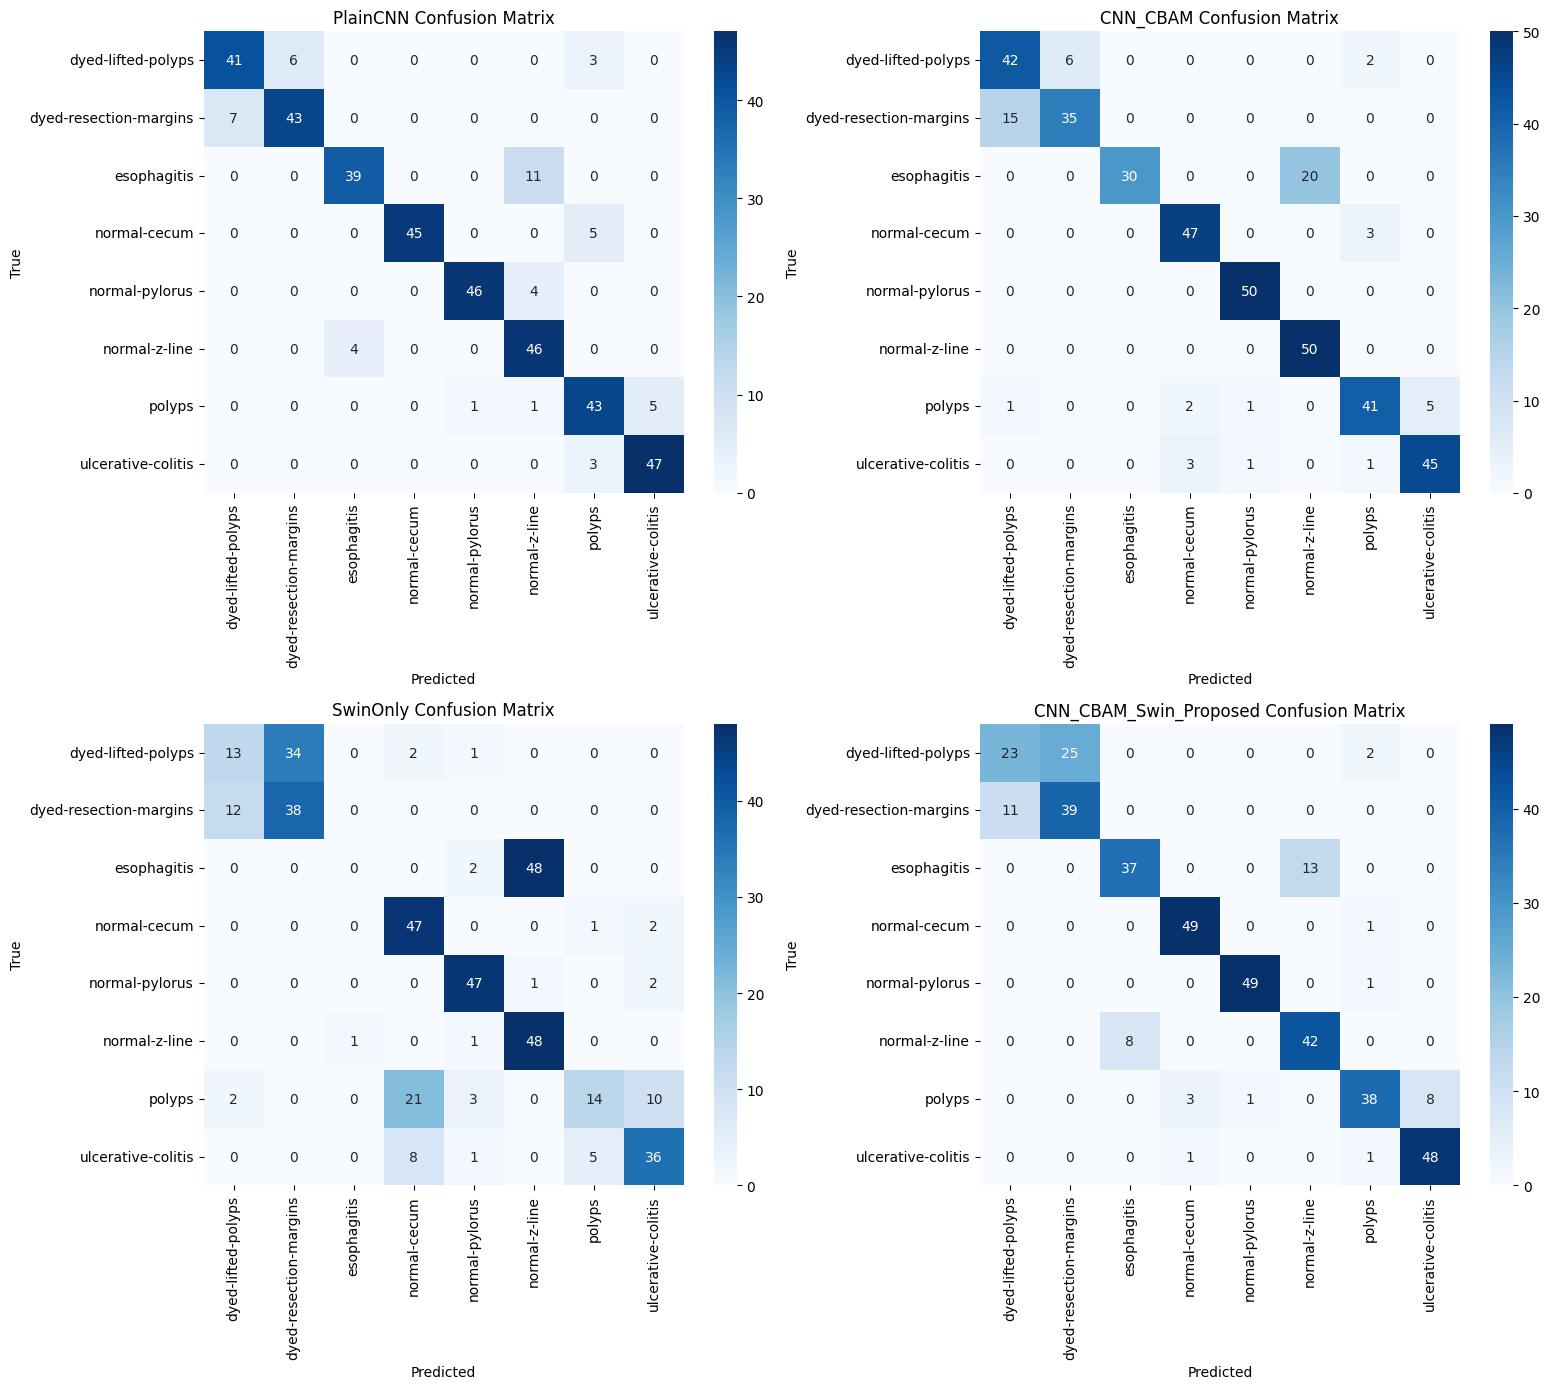

In [17]:
# ============================================================
# 17. TABLE 5 EQUIVALENT -- Confusion Matrices (all models)
# ============================================================
fig, axes = plt.subplots(2, 2, figsize=(16, 14))
for ax, (name, r) in zip(axes.flatten(), results.items()):
    sns.heatmap(r['confusion_matrix'], annot=True, fmt='d', cmap='Blues',
                xticklabels=CLASS_NAMES, yticklabels=CLASS_NAMES, ax=ax)
    ax.set_title(f'{name} Confusion Matrix')
    ax.set_xlabel('Predicted'); ax.set_ylabel('True')
plt.tight_layout()
plt.savefig('/kaggle/working/fig_confusion_matrices.png', dpi=150)
plt.show()


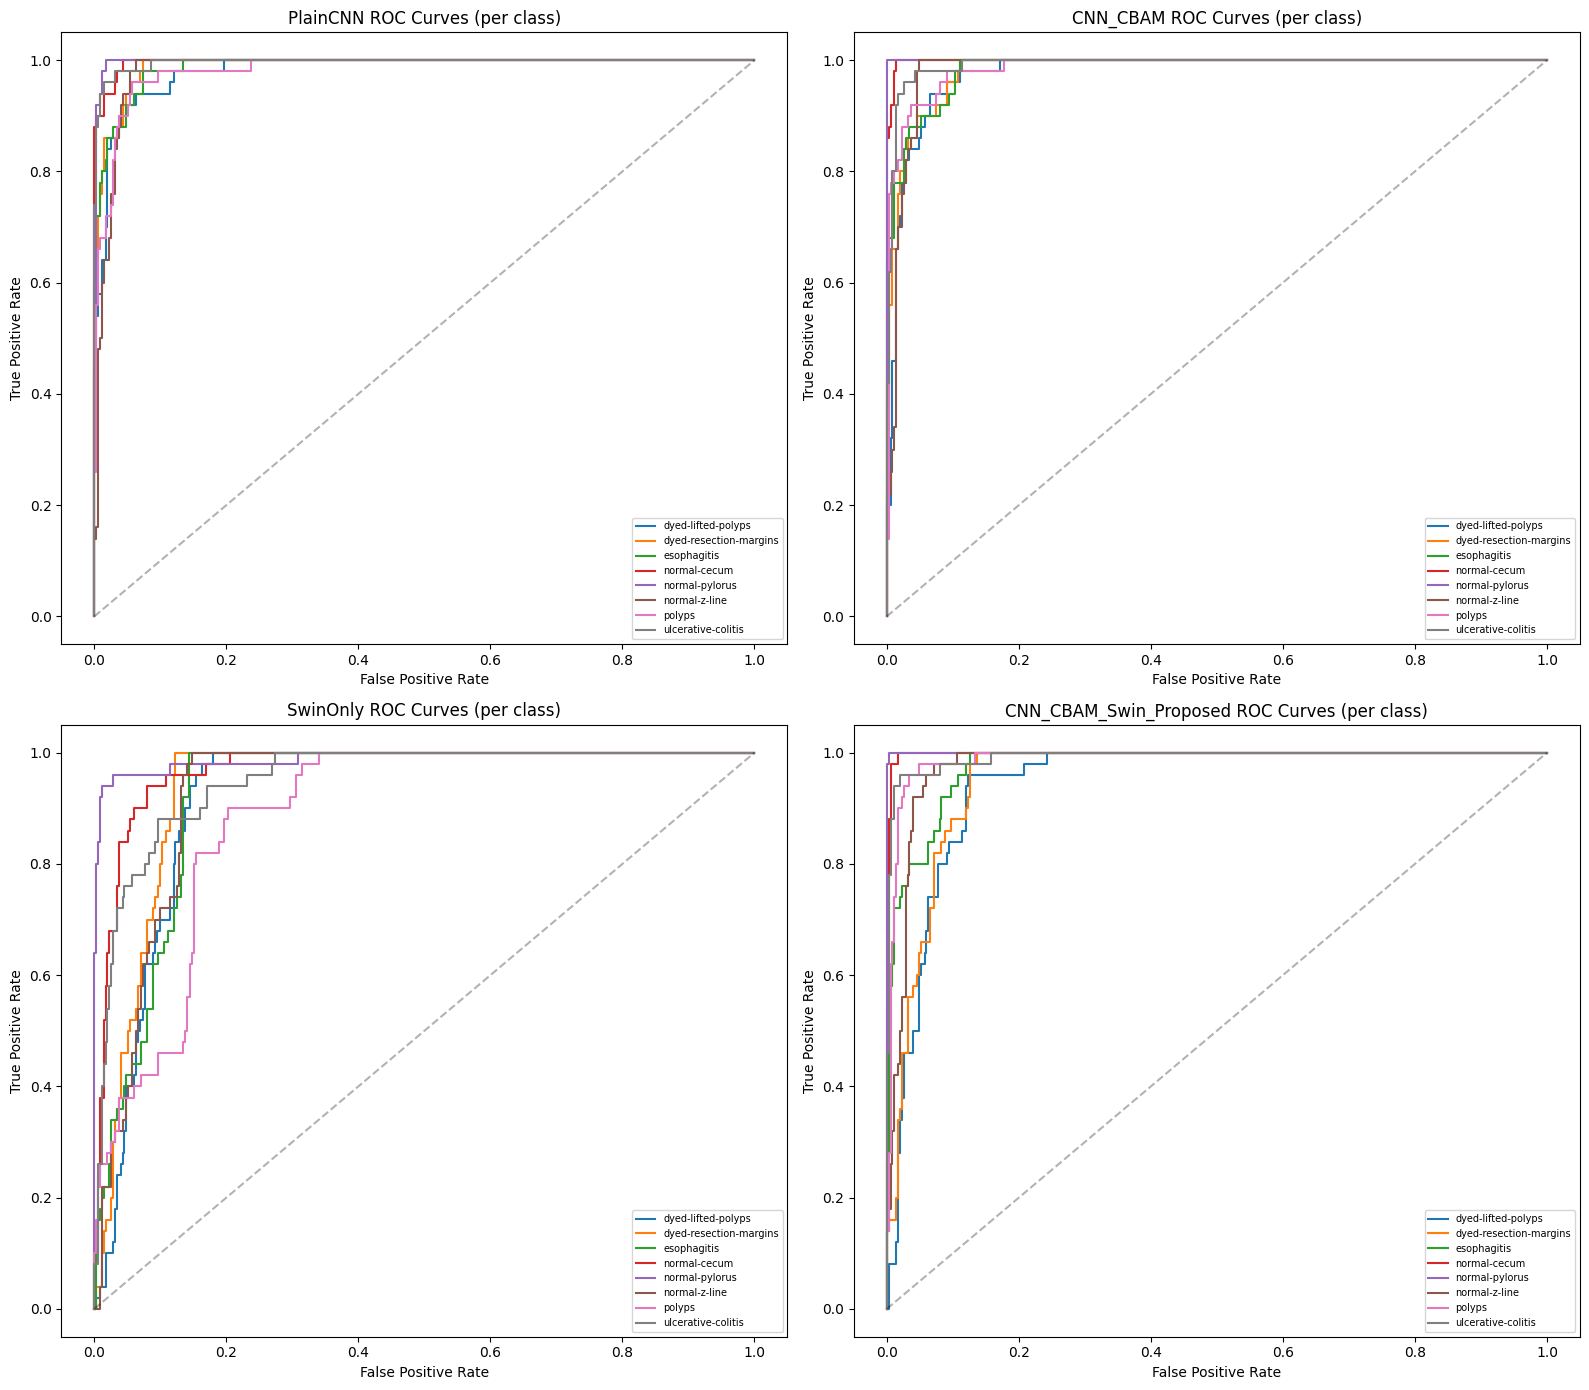

In [18]:
# ============================================================
# 18. TABLE 6 EQUIVALENT -- ROC-AUC Curves (one-vs-rest, per model)
# ============================================================
from sklearn.preprocessing import label_binarize

fig, axes = plt.subplots(2, 2, figsize=(16, 14))
for ax, (name, r) in zip(axes.flatten(), results.items()):
    y_true_bin = label_binarize(r['y_true'], classes=list(range(NUM_CLASSES)))
    for i, cname in enumerate(CLASS_NAMES):
        fpr, tpr, _ = roc_curve(y_true_bin[:, i], r['y_pred_probs'][:, i])
        ax.plot(fpr, tpr, label=f'{cname}')
    ax.plot([0, 1], [0, 1], 'k--', alpha=0.3)
    ax.set_title(f'{name} ROC Curves (per class)')
    ax.set_xlabel('False Positive Rate'); ax.set_ylabel('True Positive Rate')
    ax.legend(fontsize=7, loc='lower right')
plt.tight_layout()
plt.savefig('/kaggle/working/fig_roc_curves.png', dpi=150)
plt.show()


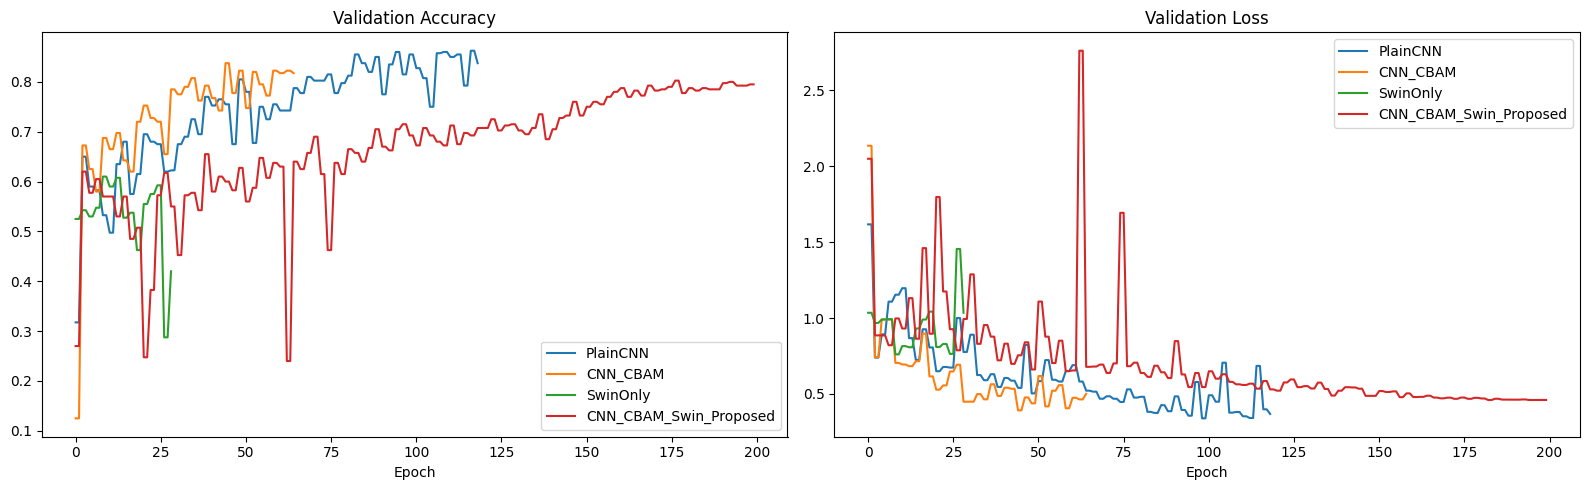

In [19]:
# ============================================================
# 19. TRAINING CURVES (Table 2 equivalent) -- Accuracy / Loss per model
# ============================================================
fig, axes = plt.subplots(1, 2, figsize=(16, 5))
for name, h in histories.items():
    axes[0].plot(h.history['val_accuracy'], label=name)
    axes[1].plot(h.history['val_loss'], label=name)
axes[0].set_title('Validation Accuracy'); axes[0].set_xlabel('Epoch'); axes[0].legend()
axes[1].set_title('Validation Loss'); axes[1].set_xlabel('Epoch'); axes[1].legend()
plt.tight_layout()
plt.savefig('/kaggle/working/fig_training_curves.png', dpi=150)
plt.show()


## Notes for the paper

- **Composite loss:** Not needed here (unlike the reference paper's Focal+Tversky+Dice combo) -- Kvasir is class-balanced (1000/class), so plain categorical cross-entropy is the correct and defensible choice. Mention this explicitly in your methodology section as a deliberate design decision, not an oversight.
- **Threshold optimization (Table 4 equivalent):** Not applicable in multi-class classification with softmax -- argmax replaces the binary threshold sweep. You can drop that table or replace it with a per-class precision/recall bar chart instead.
- **Figures 4-9 equivalent:** Use `fig_confusion_matrices.png`, `fig_roc_curves.png`, `fig_training_curves.png` as your Figures. Add a qualitative Grad-CAM visualization (attention heatmap) for a few sample images per class -- this mirrors their Figure 6/7 "best vs worst prediction" visual analysis.
- **Ethics/Data availability:** Kvasir is a public dataset (cite the original Kvasir paper by Pogorelov et al.), so this section is simpler than the reference paper's private-dataset ethics statement.
